# Module 7 — Social Welfare & Efficiency

**Research Question**: Which configurations achieve the best collective outcomes? How fair are the outcomes?

**Key Metrics**: Social welfare (total penalty), Pareto efficiency, outcome fairness, Price of Anarchy.

**Outputs**: Figure 7a (welfare landscape), Figure 7b (Pareto efficiency), Figure 7c (fairness/exploitation), Figure 7d (outcome distribution)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import ast
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

MODEL_COLORS = {
    'GPT-oss-20B': '#E69F00',
    'Mistral-7B': '#56B4E9',
    'Qwen2.5-32B': '#009E73'
}
MODEL_LABELS = {
    'gpt-oss-20b': 'GPT-oss-20B',
    'Mistral-7B-Instruct-v0.3': 'Mistral-7B',
    'Qwen2.5-32B-Instruct': 'Qwen2.5-32B'
}
LANG_LABELS = {
    'en': 'English', 'fr': 'French', 'ar': 'Arabic',
    'cn': 'Chinese', 'vn': 'Vietnamese', 'it': 'Italian'
}
NOISE_LABELS = {0.0: '0%', 0.05: '5%', 0.2: '20%'}
PERSONALITY_MAP = {
    'cooperative': 'Cooperative', 'selfish': 'Selfish',
    'coopératif': 'Cooperative', 'égoïste': 'Selfish',
    'متعاون': 'Cooperative', 'أناني': 'Selfish',
    '合作型的': 'Cooperative', '自私型的': 'Selfish',
    'một người hợp tác': 'Cooperative', 'một người ích kỷ': 'Selfish',
    'cooperativo': 'Cooperative', 'egoista': 'Selfish'
}
FIGURE_DIR = 'figures/'
import os
os.makedirs(FIGURE_DIR, exist_ok=True)

print('Setup complete.')

Setup complete.


In [2]:
DATA_PATH = '../resources/results/Prisoner_dilemma_2player/consolidated_dataset.csv'
df = pd.read_csv(DATA_PATH)
df['personality'] = df['agent1_personality'].map(PERSONALITY_MAP)
df['model'] = df['agent1_llm'].map(MODEL_LABELS)
df['lang_full'] = df['language'].map(LANG_LABELS)

# Derived welfare metrics
df['social_welfare'] = df['agent1_total_score'] + df['agent2_total_score']  # lower = better
df['score_diff'] = abs(df['agent1_total_score'] - df['agent2_total_score'])  # fairness: 0 = fair
df['exploitation'] = df['agent1_total_score'] - df['agent2_total_score']  # >0 means agent1 exploited

# Per-round outcome classification
df['a1_strats'] = df['agent1_strategies'].apply(ast.literal_eval)
df['a2_strats'] = df['agent2_strategies'].apply(ast.literal_eval)

def classify_outcomes(a1, a2):
    """Classify each round into outcome types."""
    outcomes = []
    for s1, s2 in zip(a1, a2):
        c1, c2 = s1 == 'OptionB', s2 == 'OptionB'
        if c1 and c2:
            outcomes.append('CC')
        elif c1 and not c2:
            outcomes.append('CD')
        elif not c1 and c2:
            outcomes.append('DC')
        else:
            outcomes.append('DD')
    return outcomes

df['outcomes'] = df.apply(lambda r: classify_outcomes(r['a1_strats'], r['a2_strats']), axis=1)

# Outcome rates
for oc in ['CC', 'CD', 'DC', 'DD']:
    df[f'{oc}_rate'] = df['outcomes'].apply(lambda x: x.count(oc) / len(x))

print(f'Loaded {len(df)} games.')
print(f'Social welfare range: [{df["social_welfare"].min()}, {df["social_welfare"].max()}]')
print(f'Social optimum (all CC): {60*2} = 120')
print(f'Nash equilibrium (all DD): {240*2} = 480')

Loaded 2160 games.
Social welfare range: [120, 480]
Social optimum (all CC): 120 = 120
Nash equilibrium (all DD): 480 = 480


## 7.1 Figure 7a — Social Welfare Landscape

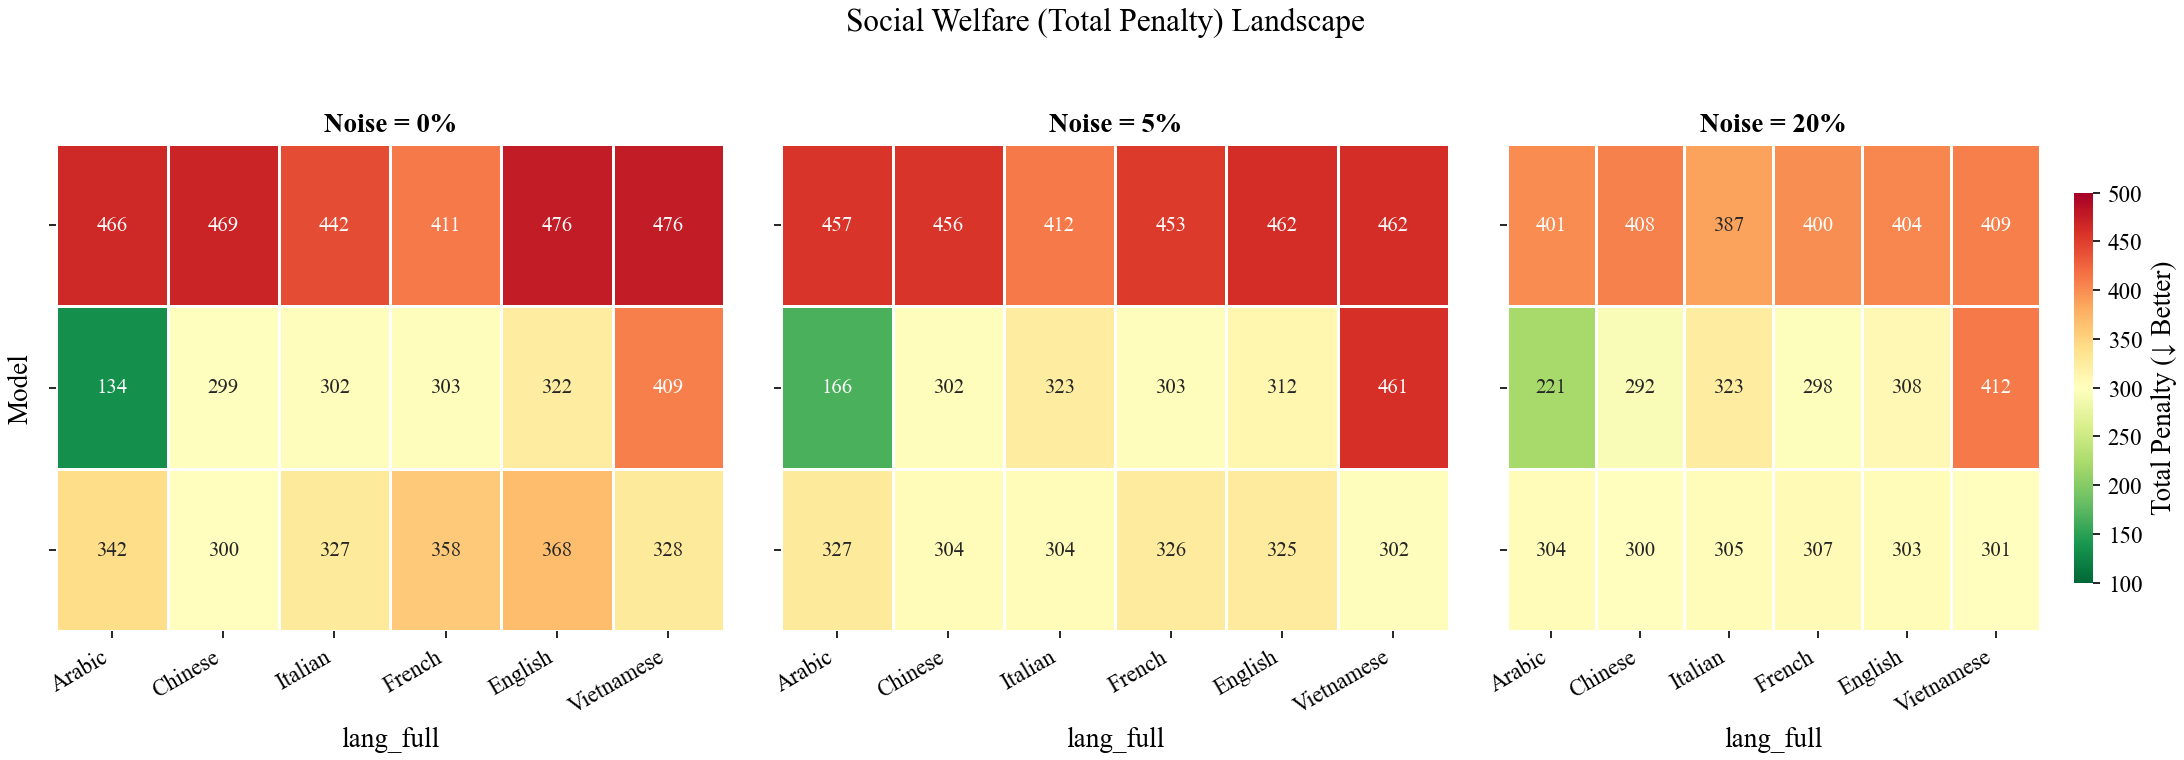

Saved: fig7a_welfare_landscape.pdf/png


In [3]:
# ── Figure 7a: Social welfare by Model × Language × Noise ──
models_order = ['GPT-oss-20B', 'Mistral-7B', 'Qwen2.5-32B']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
noise_levels = [0.0, 0.05, 0.2]
lang_order = ['Arabic', 'Chinese', 'Italian', 'French', 'English', 'Vietnamese']

for idx, noise in enumerate(noise_levels):
    ax = axes[idx]
    sub = df[df['agent1_noise_rate'] == noise]
    
    pivot = sub.pivot_table(
        values='social_welfare', index='model', columns='lang_full', aggfunc='mean'
    ).reindex(models_order)
    # Reorder columns
    cols = [c for c in lang_order if c in pivot.columns]
    pivot = pivot[cols]
    
    sns.heatmap(
        pivot, annot=True, fmt='.0f', cmap='RdYlGn_r',  # reversed: red=high penalty=bad
        vmin=100, vmax=500, linewidths=0.5, linecolor='white',
        cbar=idx == 2,
        cbar_kws={'label': 'Total Penalty (↓ Better)', 'shrink': 0.8} if idx == 2 else {},
        annot_kws={'fontsize': 10}, ax=ax
    )
    ax.set_title(f'Noise = {NOISE_LABELS[noise]}', fontsize=13, fontweight='bold')
    ax.set_ylabel('' if idx > 0 else 'Model')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

fig.suptitle('Social Welfare (Total Penalty) Landscape', fontsize=15, y=1.03)

plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}fig7a_welfare_landscape.pdf')
fig.savefig(f'{FIGURE_DIR}fig7a_welfare_landscape.png')
plt.show()
print('Saved: fig7a_welfare_landscape.pdf/png')

## 7.2 Figure 7b — Outcome Distribution (CC/CD/DC/DD)

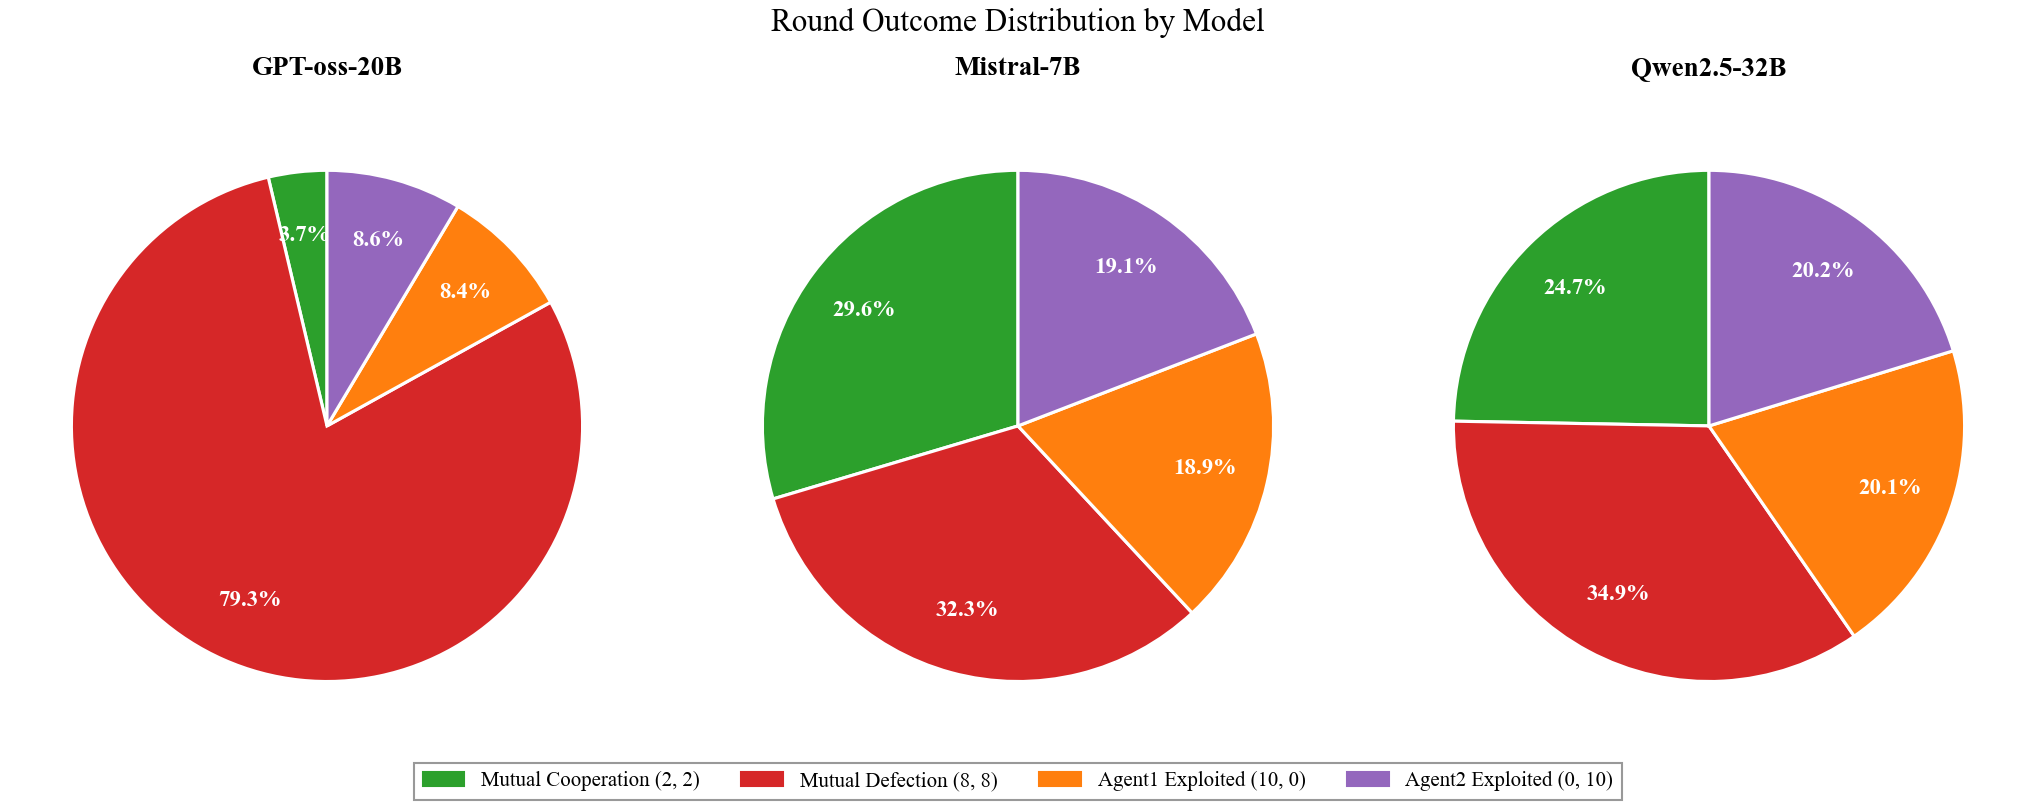

Saved: fig7b_outcome_distribution.pdf/png


In [4]:
# ── Figure 7b: Outcome type distribution per model ──
outcome_labels = {
    'CC': 'Mutual Cooperation\n(2, 2)',
    'DD': 'Mutual Defection\n(8, 8)',
    'CD': 'Agent1 Exploited\n(10, 0)',
    'DC': 'Agent2 Exploited\n(0, 10)'
}
outcome_colors = {'CC': '#2ca02c', 'DD': '#d62728', 'CD': '#ff7f0e', 'DC': '#9467bd'}

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for idx, model in enumerate(models_order):
    ax = axes[idx]
    sub = df[df['model'] == model]
    
    sizes = [sub[f'{oc}_rate'].mean() for oc in ['CC', 'DD', 'CD', 'DC']]
    labels = [outcome_labels[oc] for oc in ['CC', 'DD', 'CD', 'DC']]
    colors = [outcome_colors[oc] for oc in ['CC', 'DD', 'CD', 'DC']]
    
    wedges, texts, autotexts = ax.pie(
        sizes, labels=None, autopct='%1.1f%%',
        colors=colors, startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
        textprops={'fontsize': 11},
        pctdistance=0.75
    )
    for autotext in autotexts:
        autotext.set_fontweight('bold')
        autotext.set_color('white')
    
    ax.set_title(model, fontsize=13, fontweight='bold', pad=15)

# Shared legend
legend_patches = [mpatches.Patch(color=outcome_colors[oc], label=outcome_labels[oc].replace('\n', ' '))
                  for oc in ['CC', 'DD', 'CD', 'DC']]
fig.legend(handles=legend_patches, loc='lower center', ncol=4,
           frameon=True, fancybox=False, edgecolor='gray',
           bbox_to_anchor=(0.5, -0.05), fontsize=10)

fig.suptitle('Round Outcome Distribution by Model', fontsize=15, y=1.02)

plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}fig7b_outcome_distribution.pdf')
fig.savefig(f'{FIGURE_DIR}fig7b_outcome_distribution.png')
plt.show()
print('Saved: fig7b_outcome_distribution.pdf/png')

## 7.3 Figure 7c — Fairness: Score Differential Distribution

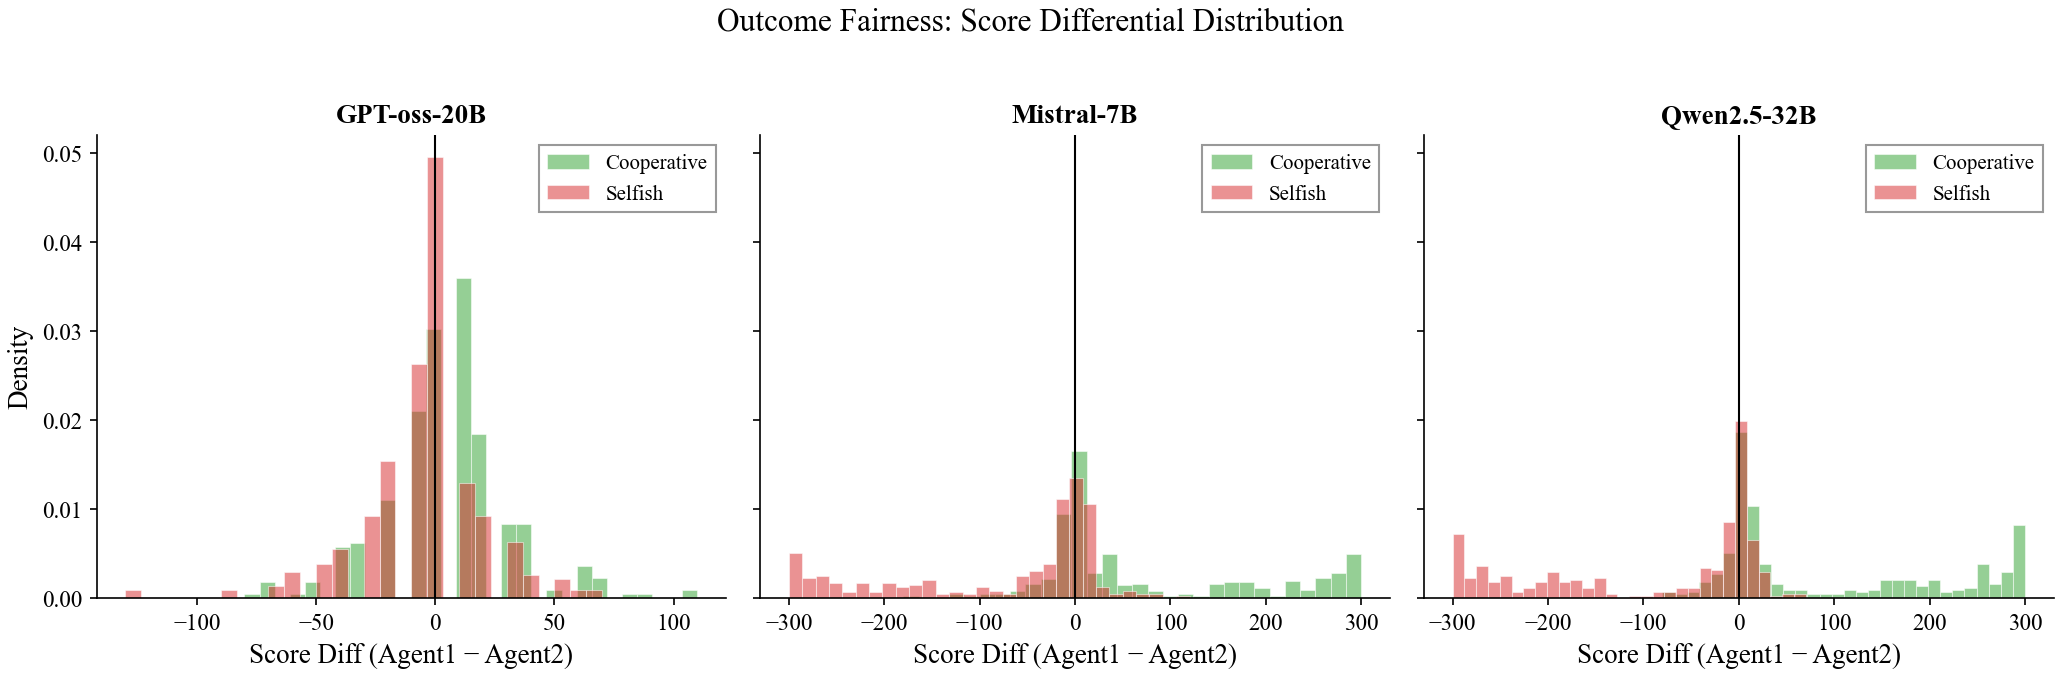

Saved: fig7c_fairness_distribution.pdf/png


In [5]:
# ── Figure 7c: Exploitation — Score difference A1 vs A2 ──
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)

for idx, model in enumerate(models_order):
    ax = axes[idx]
    sub = df[df['model'] == model]
    
    for pers, color in [('Cooperative', '#2ca02c'), ('Selfish', '#d62728')]:
        ps = sub[sub['personality'] == pers]
        ax.hist(ps['exploitation'], bins=30, alpha=0.5, color=color,
                label=pers, density=True, edgecolor='white', linewidth=0.5)
    
    ax.axvline(x=0, color='black', linewidth=1, linestyle='-')
    ax.set_xlabel('Score Diff (Agent1 − Agent2)')
    ax.set_title(model, fontsize=13, fontweight='bold')
    ax.legend(frameon=True, fancybox=False, edgecolor='gray', fontsize=10)

axes[0].set_ylabel('Density')
fig.suptitle('Outcome Fairness: Score Differential Distribution', fontsize=15, y=1.02)

plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}fig7c_fairness_distribution.pdf')
fig.savefig(f'{FIGURE_DIR}fig7c_fairness_distribution.png')
plt.show()
print('Saved: fig7c_fairness_distribution.pdf/png')

## 7.4 Figure 7d — Efficiency Scatter: Agent1 Score vs Agent2 Score

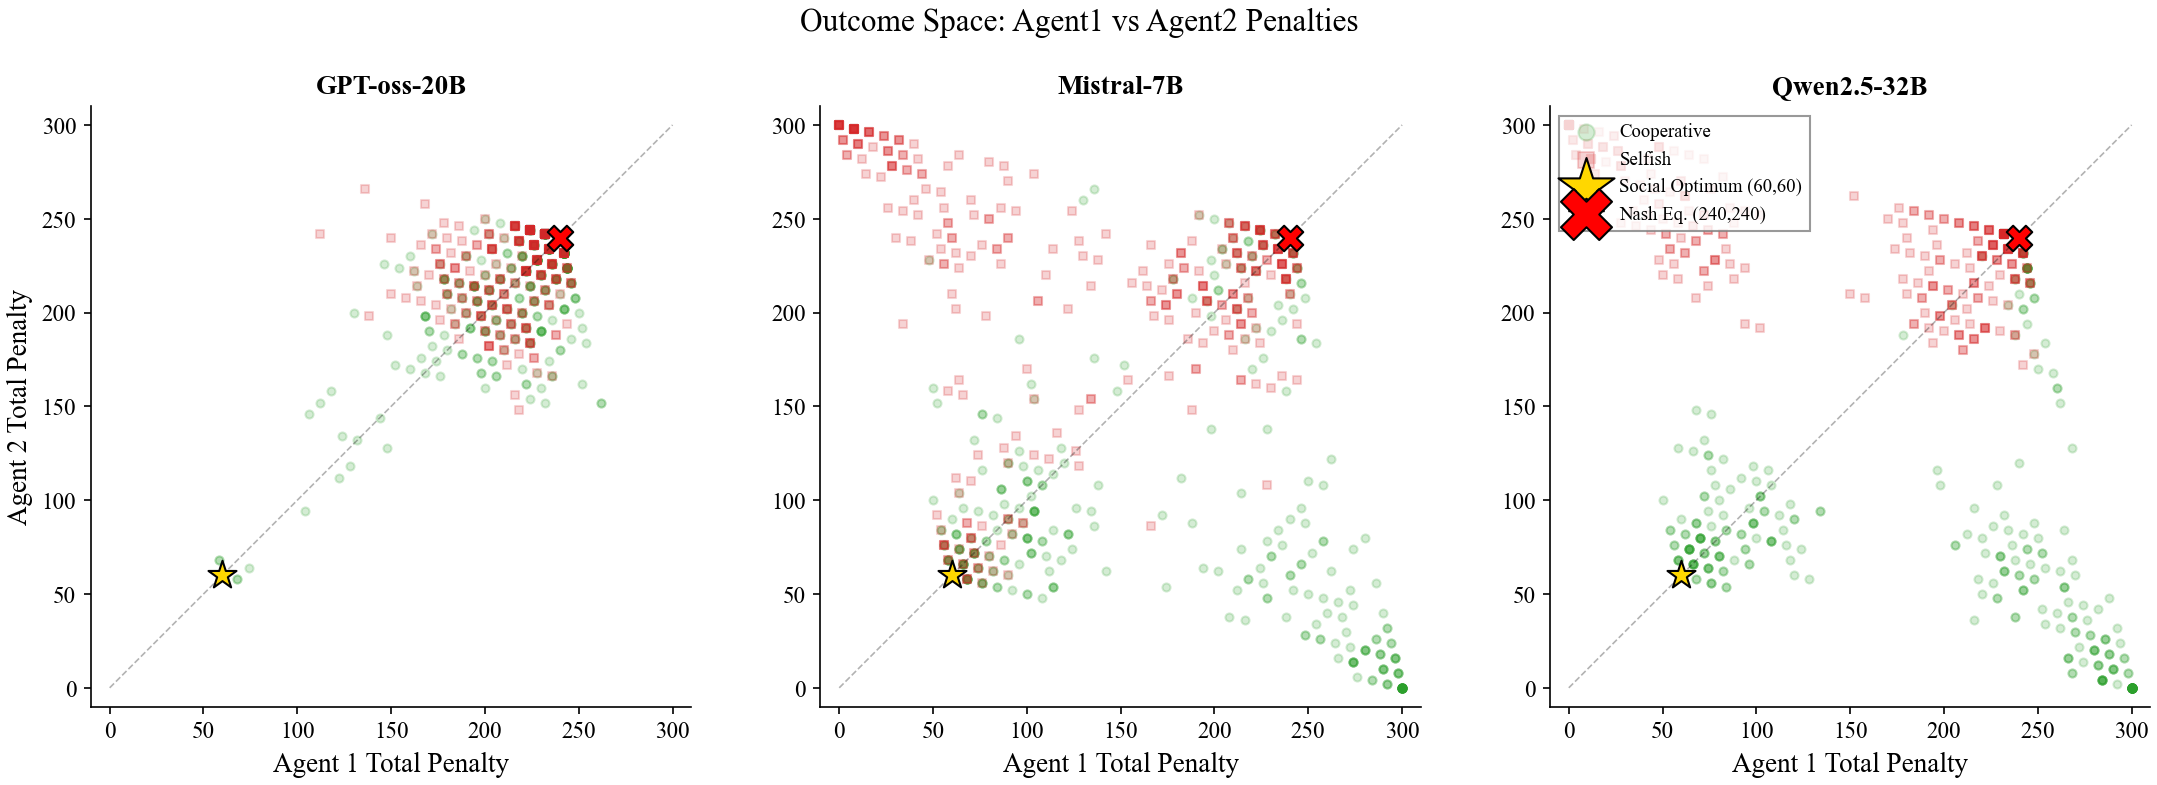

Saved: fig7d_pareto_scatter.pdf/png


In [6]:
# ── Figure 7d: Pareto scatter — Agent1 vs Agent2 total scores ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, model in enumerate(models_order):
    ax = axes[idx]
    sub = df[df['model'] == model]
    
    for pers, marker, color in [('Cooperative', 'o', '#2ca02c'), ('Selfish', 's', '#d62728')]:
        ps = sub[sub['personality'] == pers]
        ax.scatter(ps['agent1_total_score'], ps['agent2_total_score'],
                   alpha=0.2, s=15, marker=marker, color=color, label=pers)
    
    # Reference points
    ax.scatter([60], [60], marker='*', s=200, color='gold', zorder=10,
               edgecolor='black', linewidth=1, label='Social Optimum (60,60)')
    ax.scatter([240], [240], marker='X', s=150, color='red', zorder=10,
               edgecolor='black', linewidth=1, label='Nash Eq. (240,240)')
    
    # Fairness line
    ax.plot([0, 300], [0, 300], 'k--', alpha=0.3, linewidth=0.8)
    
    ax.set_xlabel('Agent 1 Total Penalty')
    ax.set_title(model, fontsize=13, fontweight='bold')
    ax.set_xlim(-10, 310)
    ax.set_ylim(-10, 310)
    ax.set_aspect('equal')
    if idx == 2:
        ax.legend(loc='upper left', frameon=True, fancybox=False,
                  edgecolor='gray', fontsize=9, markerscale=2)

axes[0].set_ylabel('Agent 2 Total Penalty')
fig.suptitle('Outcome Space: Agent1 vs Agent2 Penalties', fontsize=15, y=1.02)

plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}fig7d_pareto_scatter.pdf')
fig.savefig(f'{FIGURE_DIR}fig7d_pareto_scatter.png')
plt.show()
print('Saved: fig7d_pareto_scatter.pdf/png')

## 7.5 Summary Table — Best/Worst Configurations

In [7]:
# ── Table: Top 10 best and worst configurations by social welfare ──
config_welfare = df.groupby(['model', 'lang_full', 'agent1_noise_rate', 'personality']).agg(
    mean_welfare=('social_welfare', 'mean'),
    std_welfare=('social_welfare', 'std'),
    mean_CC=('CC_rate', 'mean'),
    mean_DD=('DD_rate', 'mean'),
    n_games=('social_welfare', 'count')
).reset_index()
config_welfare['Noise'] = config_welfare['agent1_noise_rate'].map(NOISE_LABELS)

print('=== TOP 10 BEST Configurations (Lowest Penalty = Most Cooperative) ===')
best = config_welfare.nsmallest(10, 'mean_welfare')
display(best[['model', 'lang_full', 'Noise', 'personality', 'mean_welfare', 'mean_CC', 'mean_DD']].round(2))

print('\n=== TOP 10 WORST Configurations (Highest Penalty = Most Defective) ===')
worst = config_welfare.nlargest(10, 'mean_welfare')
display(worst[['model', 'lang_full', 'Noise', 'personality', 'mean_welfare', 'mean_CC', 'mean_DD']].round(2))

=== TOP 10 BEST Configurations (Lowest Penalty = Most Cooperative) ===


,model,lang_full,Noise,personality,mean_welfare,mean_CC,mean_DD
36,Mistral-7B,Arabic,0%,Cooperative,130.5,0.94,0.00
37,Mistral-7B,Arabic,0%,Selfish,136.5,0.91,0.00
38,Mistral-7B,Arabic,5%,Cooperative,160.2,0.80,0.03
39,Mistral-7B,Arabic,5%,Selfish,171.3,0.78,0.06
40,Mistral-7B,Arabic,20%,Cooperative,209.4,0.57,0.07
78,Qwen2.5-32B,Chinese,0%,Cooperative,210.0,0.50,0.00
42,Mistral-7B,Chinese,0%,Cooperative,210.9,0.51,0.01
54,Mistral-7B,French,0%,Cooperative,213.6,0.50,0.02
60,Mistral-7B,Italian,0%,Cooperative,220.2,0.46,0.02
104,Qwen2.5-32B,Vietnamese,5%,Cooperative,221.1,0.46,0.02



=== TOP 10 WORST Configurations (Highest Penalty = Most Defective) ===


,model,lang_full,Noise,personality,mean_welfare,mean_CC,mean_DD
13,GPT-oss-20B,English,0%,Selfish,479.1,0.0,0.99
31,GPT-oss-20B,Vietnamese,0%,Selfish,479.1,0.0,0.99
7,GPT-oss-20B,Chinese,0%,Selfish,476.7,0.0,0.98
1,GPT-oss-20B,Arabic,0%,Selfish,475.8,0.0,0.98
19,GPT-oss-20B,French,0%,Selfish,474.6,0.0,0.97
25,GPT-oss-20B,Italian,0%,Selfish,474.0,0.0,0.97
12,GPT-oss-20B,English,0%,Cooperative,472.8,0.0,0.97
30,GPT-oss-20B,Vietnamese,0%,Cooperative,472.5,0.0,0.96
85,Qwen2.5-32B,English,0%,Selfish,469.2,0.0,0.94
14,GPT-oss-20B,English,5%,Cooperative,464.4,0.0,0.92


In [8]:
# ── Price of Anarchy by Model ──
print('=== Price of Anarchy ===')
print('Social Optimum (all CC, 30 rounds): 120 total penalty')
print('Nash Equilibrium (all DD, 30 rounds): 480 total penalty')
print('-' * 50)

for model in models_order:
    sub = df[df['model'] == model]
    avg_welfare = sub['social_welfare'].mean()
    # Efficiency ratio: how close to social optimum vs Nash
    efficiency = 1 - (avg_welfare - 120) / (480 - 120)  # 1=optimum, 0=Nash
    poa = avg_welfare / 120  # Price of Anarchy
    print(f'  {model}: Avg welfare={avg_welfare:.0f}, Efficiency={efficiency:.1%}, PoA={poa:.2f}')

# Overall
avg_all = df['social_welfare'].mean()
eff_all = 1 - (avg_all - 120) / (480 - 120)
print(f'  Overall: Avg welfare={avg_all:.0f}, Efficiency={eff_all:.1%}, PoA={avg_all/120:.2f}')

=== Price of Anarchy ===
Social Optimum (all CC, 30 rounds): 120 total penalty
Nash Equilibrium (all DD, 30 rounds): 480 total penalty
--------------------------------------------------
  GPT-oss-20B: Avg welfare=436, Efficiency=12.2%, PoA=3.63
  Mistral-7B: Avg welfare=305, Efficiency=48.6%, PoA=2.54
  Qwen2.5-32B: Avg welfare=318, Efficiency=44.9%, PoA=2.65
  Overall: Avg welfare=353, Efficiency=35.2%, PoA=2.94
